In [1]:
import numpy as np
import pandas as pd

In [3]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/Datasets/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Datasets/Match_dataset_clean.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [2]:
from Data.data_preparing import DataPreparer

preparer = DataPreparer(match_data_filepath="Data/Datasets/Match_dataset_clean.csv",
                        market_value_filepath="Data/Datasets/ligue1_market_values_2010_2025.csv")

# Save Features DataFrame
preparer.feature_engineering(save=True, display=False)

df = preparer.merge_df(save=True)

Processing complete. Saving merged dataframe to 'Complete_df.csv'.


In [2]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Datasets/Complete_df.csv")

train_df, test_df = processer.split_train_test(test_season='24-25')

train_data_BT, test_data = processer.get_train_test_data_BT()

feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

train_data_NBTR = processer.get_data_NBTR(feature_names=feature_names)

In [ ]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data_BT)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

In [3]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data_BT)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


Training with hidden_dim=8, lr=0.001
Training with hidden_dim=8, lr=0.005
Training with hidden_dim=8, lr=0.01
Training with hidden_dim=8, lr=0.05
Training with hidden_dim=16, lr=0.001
Training with hidden_dim=16, lr=0.005
Training with hidden_dim=16, lr=0.01
Training with hidden_dim=16, lr=0.05
Training with hidden_dim=32, lr=0.001
Training with hidden_dim=32, lr=0.005
Training with hidden_dim=32, lr=0.01
Training with hidden_dim=32, lr=0.05
Training with hidden_dim=64, lr=0.001
Training with hidden_dim=64, lr=0.005
Training with hidden_dim=64, lr=0.01
Training with hidden_dim=64, lr=0.05


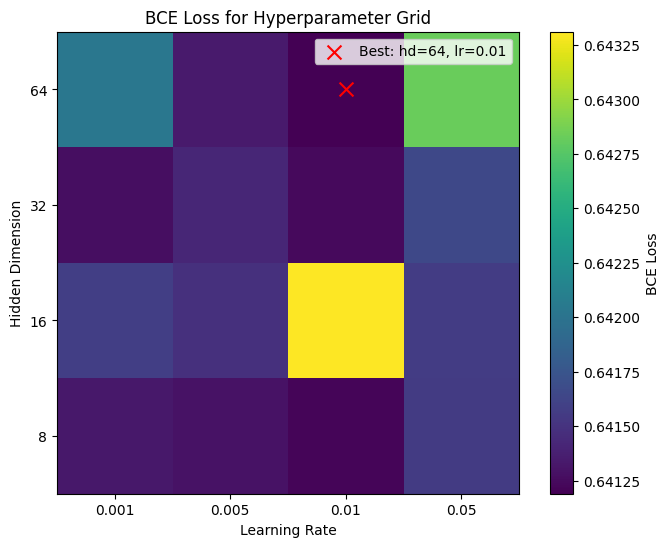

Optimal hidden_dim: 64, Optimal lr: 0.01, Minimum BCE Loss: 0.6411893963813782


In [1]:
from Neural_Bradley_Terry.calibrate import NBTR_calibrate

calibrator = NBTR_calibrate(train_data_filepath='Data/Datasets/Complete_df.csv')
hidden_dims = [8, 16, 32, 64]
lrs = [0.001, 0.005, 0.01, 0.05]
best_hd, best_lr, min_loss = calibrator.calibrate_hyperparams(hidden_dims, lrs)
print(f"Optimal hidden_dim: {best_hd}, Optimal lr: {best_lr}, Minimum BCE Loss: {min_loss}")

In [ ]:
# Best hyperparameters found : Optimal hidden_dim: 64, Optimal lr: 0.01

In [2]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry

NBTR_model = NeuralBradleyTerry(input_dim=train_data_NBTR['input_dim'], hidden_dim=64, lr=0.01)

NBTR_model.fit(train_data_NBTR['X_home'], train_data_NBTR['X_away'], train_data_NBTR['y'], epochs=500)


NameError: name 'train_data_NBTR' is not defined

In [5]:
NBTR_strength = NBTR_model.get_season_ranking(test_df=test_df, feature_cols=feature_names)
NBTR_probas = NBTR_model.predict_season_probas(test_df=test_df, feature_cols=feature_names)

In [6]:
BT_strength = strength
BT_probas = bt_model.simulate_season(list_teams=test_data['Teams'])

In [7]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate = BT_evaluate_strengths(BT_results=BT_strength, NBTR_results=NBTR_strength, test_df=test_df)

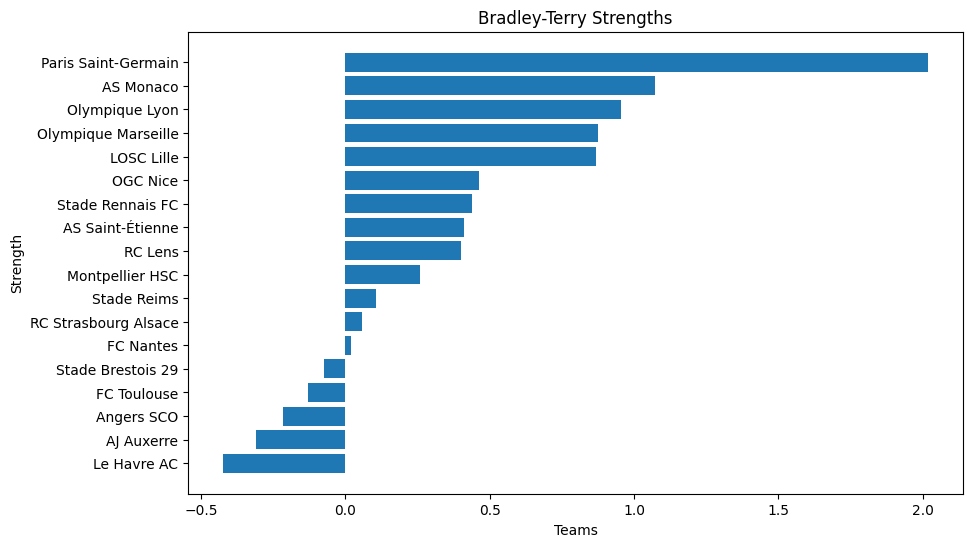

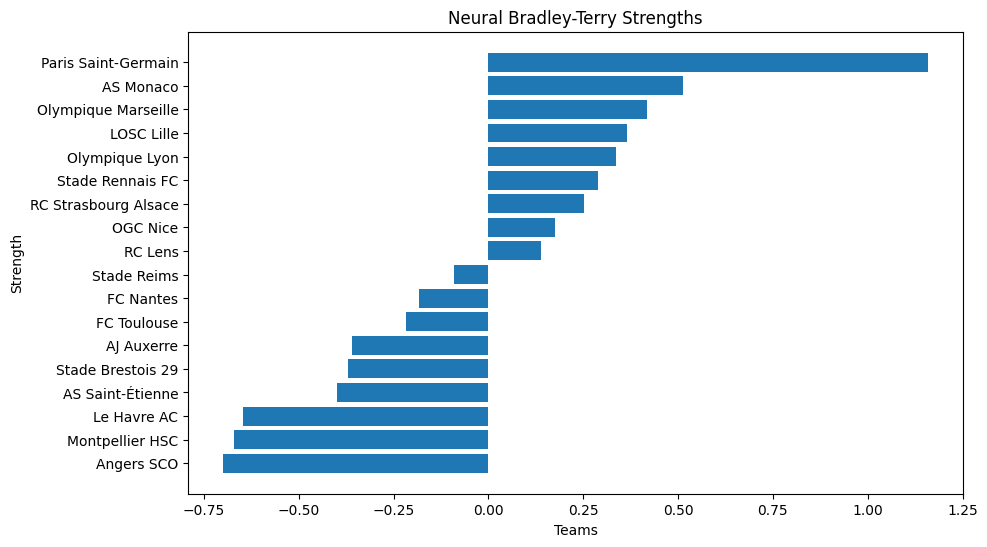

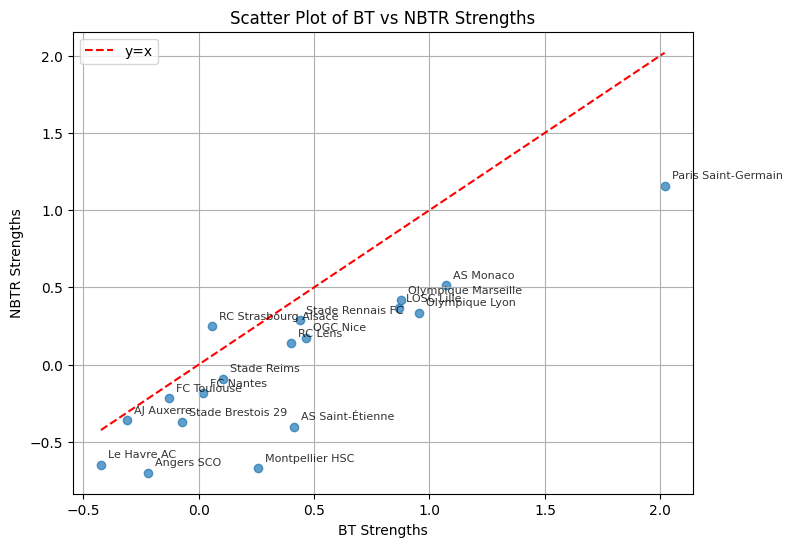

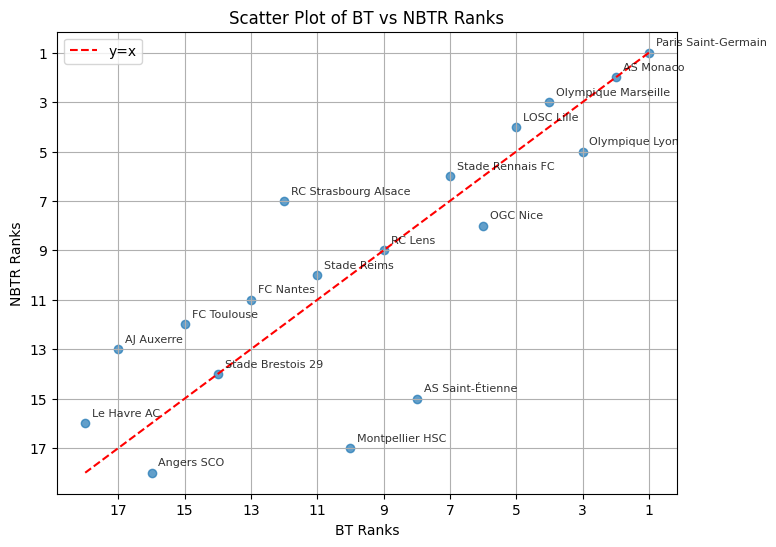

Pearson correlation: {'correlation': np.float64(0.8708383314553435), 'pvalue': np.float64(2.5769897881760243e-06), 'ci_lower': np.float64(0.6236237561182526), 'ci_upper': np.float64(0.9640908515947967)}
Spearman correlation: {'correlation': np.float64(0.8224974200206397), 'pvalue': np.float64(2.7926170666106315e-05), 'ci_lower': np.float64(0.5240520273539142), 'ci_upper': np.float64(0.9709114632990287)}
Results correlation (points, BT): {'correlation': np.float64(0.6390913358878553), 'pvalue': np.float64(0.004299097971605389), 'ci_lower': np.float64(0.15681757174583758), 'ci_upper': np.float64(0.8829887218665639)}
Results correlation (points, NBTR): {'correlation': np.float64(0.8386781123059072), 'pvalue': np.float64(1.3721507556773133e-05), 'ci_lower': np.float64(0.5447509053632699), 'ci_upper': np.float64(0.9514504810481332)}
Results correlation (points, BT): {'correlation': np.float64(0.6829379562335968), 'pvalue': np.float64(0.0017862357741969576), 'ci_lower': np.float64(0.27763833

In [8]:
# Test all methods of BT_evaluate_strengths

# Plot strengths for BT
Evaluate.plot_strengths('BT')

# Plot strengths for NBTR
Evaluate.plot_strengths('NBTR')

# Scatter plot of strengths
Evaluate.plot_scatter_strengths()

# Scatter plot of ranks
Evaluate.plot_scatter_ranks()

# Pearson correlation
print("Pearson correlation:", Evaluate.pearson_correlation())

# Spearman correlation
print("Spearman correlation:", Evaluate.spearman_correlation())

# Results correlation for points
print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'points'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'points'))

print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'winrate'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'winrate'))

In [9]:
from Test.test_BT_classical import BT_evaluate_probas

evaluator_probas = BT_evaluate_probas(BT_results=BT_probas, NBTR_results=NBTR_probas, test_df=test_df)

Log-loss BT: 1.005558437525326
Log-loss NBTR: 0.9664229676549466
Accuracy BT: 0.5228758169934641
Accuracy NBTR: 0.5490196078431373
Recall BT: {'H': np.float64(0.6433566433566433), 'D': np.float64(0.0), 'A': np.float64(0.6732673267326733)}
Recall NBTR: {'H': np.float64(0.6713286713286714), 'D': np.float64(0.0), 'A': np.float64(0.7128712871287128)}
Precision BT: {'H': np.float64(0.6013071895424836), 'D': 0.0, 'A': np.float64(0.4444444444444444)}
Precision NBTR: {'H': np.float64(0.6274509803921569), 'D': 0.0, 'A': np.float64(0.47058823529411764)}
Brier score BT: 0.601911069458055
Brier score NBTR: 0.5730680075744553


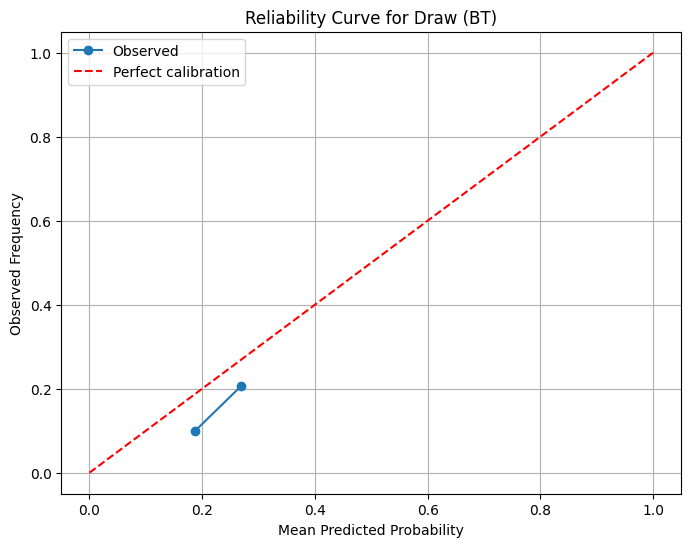

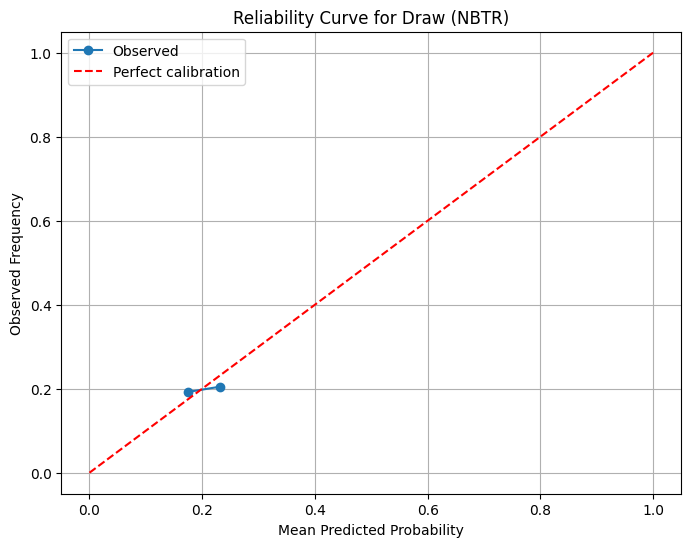

,bin_center,mean_pred_prob,observed_freq,bin_size
0,0.05,NaN,NaN,0
1,0.15,0.174558,0.192308,52
2,0.25,0.231253,0.204724,254
3,0.35,NaN,NaN,0
4,0.45,NaN,NaN,0
5,0.55,NaN,NaN,0
6,0.65,NaN,NaN,0
7,0.75,NaN,NaN,0
8,0.85,NaN,NaN,0
9,0.95,NaN,NaN,0


In [14]:
# Test all methods of BT_evaluate_probas

print("Log-loss BT:", evaluator_probas.logloss('BT'))
print("Log-loss NBTR:", evaluator_probas.logloss('NBTR'))

print("Accuracy BT:", evaluator_probas.accuracy('BT'))
print("Accuracy NBTR:", evaluator_probas.accuracy('NBTR'))

print("Recall BT:", evaluator_probas.recall('BT'))
print("Recall NBTR:", evaluator_probas.recall('NBTR'))

print("Precision BT:", evaluator_probas.precision('BT'))
print("Precision NBTR:", evaluator_probas.precision('NBTR'))

print("Brier score BT:", evaluator_probas.brier_score('BT'))
print("Brier score NBTR:", evaluator_probas.brier_score('NBTR'))

# plot reliability curve
evaluator_probas.reliability_curve_draw('BT', plot=True)

evaluator_probas.reliability_curve_draw('NBTR',plot=True)

In [21]:
evaluator_probas.results['Result_NBTR'].value_counts()

Result_NBTR
A    153
H    153
Name: count, dtype: int64